# MHE robusto con pérdida de Huber 

In [1]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import casadi as cs
from herramientas import *

## Cargar datos de sensores

In [2]:
# Cargar datos del GPS
gps_filename = 'gps_x_y_vx_vy.npz'
gps_data = np.load(gps_filename)['arr_0']

gps_t = gps_data[0]
gps_x, gps_y, _ = gps_data[1], gps_data[2], gps_data[3]
gps_vx, gps_vy, _ = gps_data[4], gps_data[5], gps_data[6]

# Cargar datos del IMU
imu_filename = 'imu_ax_ay.npz'
imu_data = np.load(imu_filename)['arr_0']
imu_t = imu_data[0]  # Extraer timestamps del IMU

In [3]:
# Sincronizar datos del IMU con los timestamps del GPS
idxs = np.searchsorted(imu_t, gps_t)

# Asegurarse de no exceder los límites
idxs = np.clip(idxs, 1, len(imu_t) - 1)
before = idxs - 1
after = idxs

# Elegir el timestamp más cercano del IMU para cada timestamp del GPS
choose_before = (gps_t - imu_t[before]) <= (imu_t[after] - gps_t)
closest_idxs = np.where(choose_before, before, after)

# Filtrar datos del IMU para que coincidan con los timestamps del GPS
imu_data_filtered = imu_data[:, closest_idxs]

In [4]:
# Ajustar los timestamps para que comiencen desde cero
gps_t = gps_t - gps_t[0]

# Extraer datos del IMU y ajustar timestamps
imu_t = imu_data_filtered[0] - imu_data_filtered[0, 0]
imu_ax, imu_ay = imu_data_filtered[1], imu_data_filtered[2]

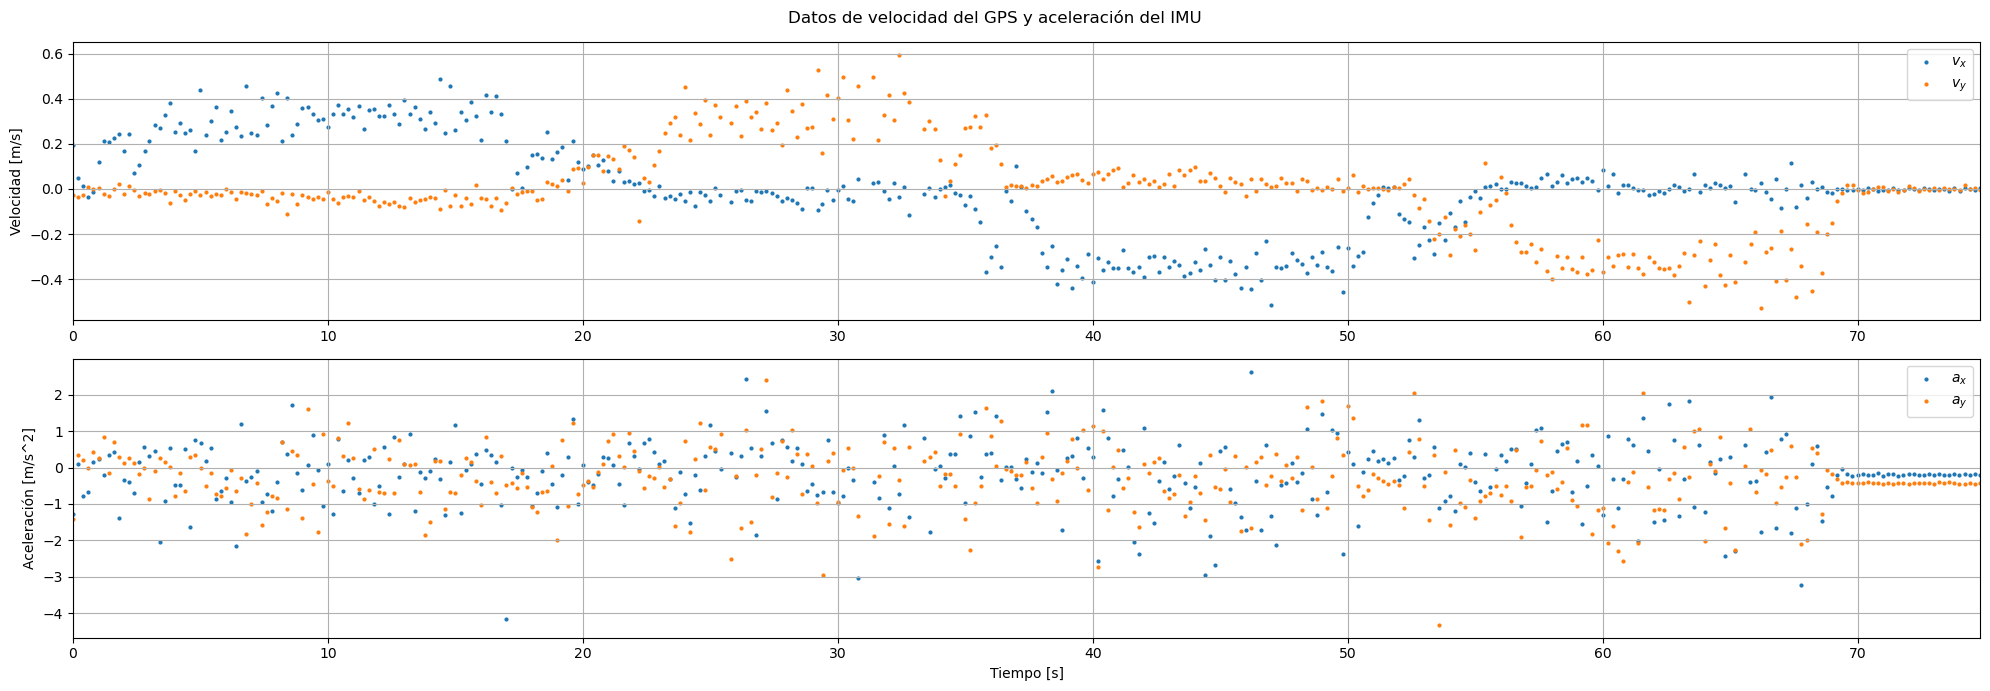

In [5]:
# Graficar velocidades del GPS y aceleraciones del IMU
plt.figure(figsize=(20, 7))

# Subplot para velocidades del GPS
ax1 = plt.subplot(211)
ax1.scatter(gps_t, gps_vx, s=4, label=r"$v_x$")
ax1.scatter(gps_t, gps_vy, s=4, label=r"$v_y$")
plt.xlim((gps_t[0], gps_t[-1]))
plt.ylabel("Velocidad [m/s]")
plt.legend()
plt.grid()

# Subplot para aceleraciones del IMU
plt.subplot(212, sharex=ax1)
plt.scatter(imu_t, imu_ax, s=4, label=r"$a_x$")
plt.scatter(imu_t, imu_ay, s=4, label=r"$a_y$")
plt.ylabel("Aceleración [m/s^2]")
plt.xlabel("Tiempo [s]")
plt.suptitle('Datos de velocidad del GPS y aceleración del IMU')
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

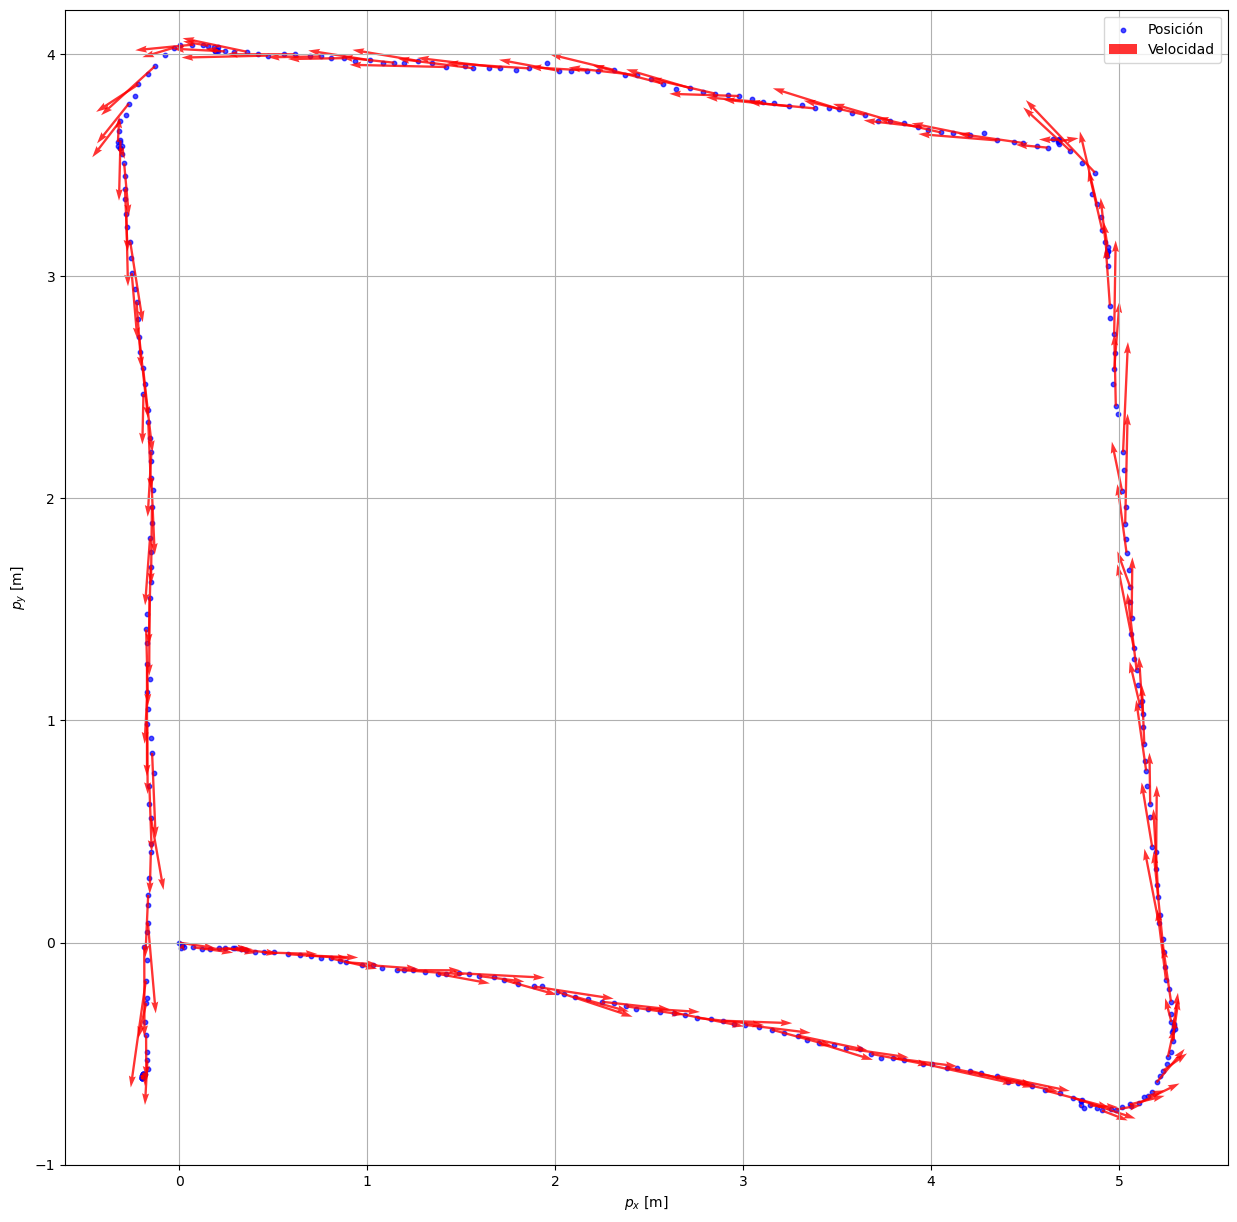

In [6]:
# Graficar trayectoria del GPS con vectores de velocidad
plt.figure(figsize=(15, 15))

plt.scatter(gps_x, gps_y, label='Posición', color='b', alpha=0.7, s=10)
plt.quiver(gps_x[::2], gps_y[::2], gps_vx[::2], gps_vy[::2],
           angles='xy', scale_units='xy', scale=1, width=0.002, color='red', label='Velocidad', alpha=0.8)

plt.xlabel('$p_x$ [m]')
plt.ylabel('$p_y$ [m]')
plt.ylim([-1, 4.2])
plt.grid(True)
plt.legend()
plt.savefig('gps_trajectory.pdf', bbox_inches='tight')
plt.show()

In [7]:
# Calcular el intervalo promedio de muestreo para GPS y IMU
delta_t = [gps_t[i+1] - gps_t[i] for i in range(len(gps_t) - 1)]
dt = np.mean(delta_t)  # Intervalo promedio de muestreo
# 0.05 s para IMU
# 0.2 s para GPS

## Configuración de parámetros y dimensiones del sistema

In [8]:
# Configuración de parámetros del sistema
USE_IMU = True            # Usar IMU o ruido aleatorio
ADD_OUTLIERS = True       # Agregar outliers a los datos del GPS
MEDIR_VELOCIDAD = False   # Medir velocidad o no

# Dimensiones del sistema
Ny = 4  # Cantidad de mediciones
Nx = 4  # Cantidad de estados
Nu = 2 if USE_IMU else 0  # Cantidad de entradas
Nv = Ny  # Cantidad de ruido de medición
Nw = 4  # Cantidad de ruido del proceso
Nsim = np.size(gps_t)  # Número de pasos de tiempo
N = 10  # Tamaño de la ventana para MHE
N_dict = {'x': Nx, 'u': Nu, 'y': Ny, 'w': Nw, 't': N}  # Diccionario de dimensiones

# Matrices de covarianza
Q = 10.0 * cs.DM.eye(Nw)  # Matriz de covarianza del ruido del proceso
R = 0.1 * cs.DM.eye(Ny)   # Matriz de covarianza del ruido de medición

# Matrices del modelo
A = np.zeros((Nx, Nx))
B = np.zeros((Nx, Nu))
C = np.zeros((Ny, Nx))
D = np.eye(Nw)
A[0, 0] = A[1, 1] = A[2, 2] = A[3, 3] = 1
A[0, 2] = A[1, 3] = dt

if USE_IMU:
    B[0, 0] = B[1, 1] = dt**2 / 2
    B[2, 0] = B[3, 1] = dt

C[0, 0] = C[1, 1] = 1
if MEDIR_VELOCIDAD:
    C[2, 2] = C[3, 3] = 1

# Parámetros y variables del problema
x = cs.SX.sym('x', Nx)
u = cs.SX.sym('u', Nu)
w = cs.SX.sym('w', Nw)

# Función de estados y de medición
f_rhs = [cs.mtimes(A, x) + cs.mtimes(B, u) + w]
f_rhs = cs.vertcat(*f_rhs)

h_rhs = [cs.mtimes(C, x)]
h_rhs = cs.vertcat(*h_rhs)

f = cs.Function('f_discrete', [x, u, w], [f_rhs], ['x', 'u', 'w'], ['f_rhs'])
h = cs.Function('h', [x], [h_rhs], ['x'], ['h_rhs'])

### Mediciones y entradas del sistema

In [9]:
# Configuración de mediciones y entradas
y_meas = np.vstack((gps_x, gps_y, gps_vx, gps_vy))  # Mediciones del GPS
x_meas = np.vstack((gps_x, gps_y, gps_vx, gps_vy))  # Estados del sistema

if USE_IMU:
    u_sim = np.vstack((imu_ax, imu_ay))  # Entradas del sistema
else:
    u_sim = np.zeros((Nu, Nsim))

# Generar ruido
np.random.seed(42)
v_sim = np.zeros((Nv, Nsim))

# Agregar outliers al ruido
sigma_p = 1.5  # Desviación estándar de los outliers en la posición
sigma_v = 0.05  # Desviación estándar de los outliers en la velocidad
p = 0.10  # Probabilidad de outliers
np.random.seed(35)
inds = np.random.rand(Nsim) <= p  # Índices de los outliers
v_sim[0:2, inds] = sigma_p * np.random.randn(2, Nsim)[:, inds]  # Outliers en posición
v_sim[2:4, inds] = sigma_v * np.random.randn(2, Nsim)[:, inds]  # Outliers en velocidad
y_noisy = y_meas + v_sim

# Errores de posición y velocidad
# Error de posición: 1.5 m
# Error de velocidad: 0.05 m/s

### Parámetros a usar

In [10]:
# Calcular jacobianos y definir parámetros iniciales
F, H, W = jacobiano(f, 0), jacobiano(h, 0), jacobiano(f, 2)
P_0 = cs.DM.eye(Nx)  # Matriz de peso de costo de arribo propuesta
x_0 = np.array([0, 0, 0, 0])  # Estado inicial propuesto

In [11]:
# Buscar el mejor parámetro rho para Huber
rhos = [0.01, 0.05, 0.1, 0.25, 0.5, 1, 1.345, 2, 5, 10]
best_rho = None
menor_error = float('inf')

for rho in rhos:
    x_huber, _, _, t_huber, _ = resolver_mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R, 
                                             F, W, H, mhe_method='KF', huber_rho=rho)
    mse_mheh = np.mean(np.square(x_huber - x_meas).mean(axis=1))
    if mse_mheh < menor_error:
        menor_error = mse_mheh
        best_rho = rho
    print(f'rho = {rho:0.3f}, MSE = {mse_mheh}')

print(f'-- Mejor rho = {best_rho:0.3f} --')


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

rho = 0.010, MSE = 0.12060559330653646
rho = 0.050, MSE = 0.1104170343080969
rho = 0.100, MSE = 0.13310724055462594
rho = 0.250, MSE = 0.17477851180376558
rho = 0.500, MSE = 0.18632364791455686
rho = 1.000, MSE = 0.18824298839859607
rho = 1.345, MSE = 0.18824298839859607
rho = 2.000, MSE = 0.18824298839859607
rho = 5.000, MSE = 0.18824298839859607
rho = 10.000, MSE = 0.18824298839859607
-- Mejor rho = 0.050 --


## Estimación

In [12]:
# Resolver el problema de MHE y variantes
x_mhe, _, _, t_mhe, _ = resolver_mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R, 
                                     F, W, H, mhe_method='KF')

x_huber, _, _, t_huber, _ = resolver_mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R, 
                                         F, W, H, mhe_method='KF', huber_rho=best_rho)

x_ekf, t_ekf = resolver_ekf(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R, 
                            f_jacx=F, f_jacw=W, h_jacx=H)

### Tablas de resultados

In [13]:
# Calcular errores y tiempos de cómputo
imu = {False: 'sin IMU', True: 'con IMU'}[USE_IMU]
vel = {False: 'sin medición de velocidad', True: 'con medición de velocidad'}[MEDIR_VELOCIDAD]
print(f'Errores ({imu}, {vel}):')

mse_ekf = np.square(x_ekf - x_meas).mean(axis=1)
mse_mhe = np.square(x_mhe - x_meas).mean(axis=1)
mse_mheh = np.square(x_huber - x_meas).mean(axis=1)

print('_' * 26)
print('    |  EKF | MHE  |MHE-H |')
print(f'| x |{mse_ekf[0]:0.4f}|{mse_mhe[0]:0.4f}|{mse_mheh[0]:0.4f}|')
print(f'| y |{mse_ekf[1]:0.4f}|{mse_mhe[1]:0.4f}|{mse_mheh[1]:0.4f}|')
print(f'|v_x|{mse_ekf[2]:0.4f}|{mse_mhe[2]:0.4f}|{mse_mheh[2]:0.4f}|')
print(f'|v_y|{mse_ekf[3]:0.4f}|{mse_mhe[3]:0.4f}|{mse_mheh[3]:0.4f}|')
print(f'|mea|{np.mean(mse_ekf):0.4f}|{np.mean(mse_mhe):0.4f}|{np.mean(mse_mheh):0.4f}|')
print(f'|MCT|{np.mean(t_ekf) * 1000:0.4f}|{np.mean(t_mhe) * 1000:0.4f}|{np.mean(t_huber) * 1000:0.4f}|')
print('_' * 26)

Errores (con IMU, sin medición de velocidad):
__________________________
    |  EKF | MHE  |MHE-H |
| x |0.0933|0.0922|0.0241|
| y |0.1850|0.1815|0.0339|
|v_x|0.2027|0.1938|0.1525|
|v_y|0.3652|0.3471|0.2311|
|mea|0.2115|0.2037|0.1104|
|MCT|0.3496|2.9982|5.7435|
__________________________


In [14]:
# Calcular errores de posición y velocidad
pe_ekf = np.sqrt(np.square(np.array(x_ekf)[0, :] - x_meas[0, :]) + np.square(np.array(x_ekf)[1, :] - x_meas[1, :]))
pe_mhe = np.sqrt(np.square(np.array(x_mhe)[0, :] - x_meas[0, :]) + np.square(np.array(x_mhe)[1, :] - x_meas[1, :]))
pe_mheh = np.sqrt(np.square(np.array(x_huber)[0, :] - x_meas[0, :]) + np.square(np.array(x_huber)[1, :] - x_meas[1, :]))

mpe_ekf = np.mean(pe_ekf)
mpe_mhe = np.mean(pe_mhe)
mpe_mheh = np.mean(pe_mheh)

MPE_ekf = np.max(pe_ekf)
MPE_mhe = np.max(pe_mhe)
MPE_mheh = np.max(pe_mheh)

v_e = np.sqrt(np.square(np.array(x_ekf)[2, :] - x_meas[2, :]) + np.square(np.array(x_ekf)[3, :] - x_meas[3, :]))
v_m = np.sqrt(np.square(np.array(x_mhe)[2, :] - x_meas[2, :]) + np.square(np.array(x_mhe)[3, :] - x_meas[3, :]))
v_h = np.sqrt(np.square(np.array(x_huber)[2, :] - x_meas[2, :]) + np.square(np.array(x_huber)[3, :] - x_meas[3, :]))

mve_ekf = np.mean(v_e)
mve_mhe = np.mean(v_m)
mve_mheh = np.mean(v_h)

MVE_ekf = np.max(v_e)
MVE_mhe = np.max(v_m)
MVE_mheh = np.max(v_h)

print('_' * 49)
print('                           |  EKF | MHE  |MHE-H |')
print(f'|Mean position error [m]   |{mpe_ekf:0.4f}|{mpe_mhe:0.4f}|{mpe_mheh:0.4f}|')
print(f'|Max position error [m]    |{MPE_ekf:0.4f}|{MPE_mhe:0.4f}|{MPE_mheh:0.4f}|')
print(f'|Mean velocity error [m/s] |{mve_ekf:0.4f}|{mve_mhe:0.4f}|{mve_mheh:0.4f}|')
print(f'|Max velocity error [m/s]  |{MVE_ekf:0.4f}|{MVE_mhe:0.4f}|{MVE_mheh:0.4f}|')
print(f'|Mean computation time [ms]|{np.mean(t_ekf) * 1000:0.4f}|{np.mean(t_mhe) * 1000:0.4f}|{np.mean(t_huber) * 1000:0.4f}|')
print('_' * 49)

_________________________________________________
                           |  EKF | MHE  |MHE-H |
|Mean position error [m]   |0.1748|0.1269|0.0950|
|Max position error [m]    |4.1692|4.0910|1.3069|
|Mean velocity error [m/s] |0.6045|0.5755|0.5336|
|Max velocity error [m/s]  |3.2847|3.5005|2.1820|
|Mean computation time [ms]|0.3496|2.9982|5.7435|
_________________________________________________


### Gráficas de resultados

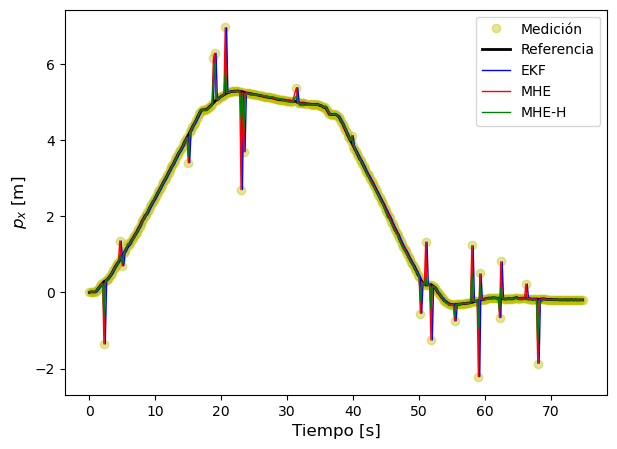

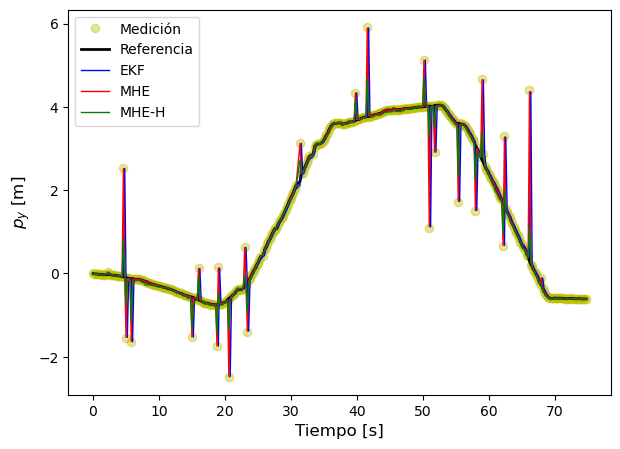

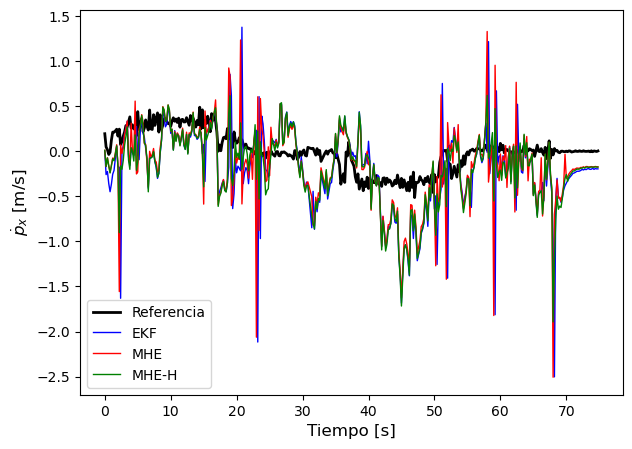

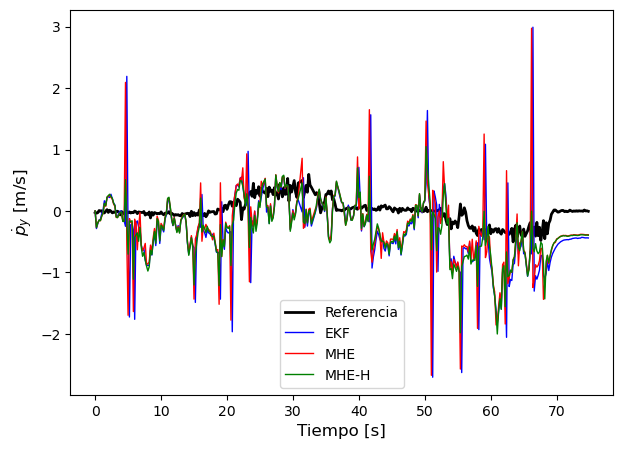

In [15]:
# Graficar estimaciones y referencias
ploteo = True
figsize = (7, 5)
linewidth = 1

if ploteo:
    plt.figure(figsize=figsize)
    plt.plot(gps_t, y_noisy[0, :], 'o', alpha=0.4, label='Medición', color='y')
    plt.plot(gps_t, gps_x, label='Referencia', color='k', linewidth=2)
    plt.plot(gps_t, np.array(x_ekf)[0, :], label='EKF', color='b', linewidth=linewidth)
    plt.plot(gps_t, np.array(x_mhe)[0, :], label='MHE', color='r', linewidth=linewidth)
    plt.plot(gps_t, np.array(x_huber)[0, :], label='MHE-H', color='g', linewidth=linewidth)
    plt.xlabel('Tiempo [s]', size=12)
    plt.ylabel('$p_x$ [m]', size=12)
    plt.legend()
    plt.savefig('gps_position_x.pdf', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=figsize)
    plt.plot(gps_t, y_noisy[1, :], 'o', alpha=0.4, label='Medición', color='y')
    plt.plot(gps_t, gps_y, label='Referencia', color='k', linewidth=2)
    plt.plot(gps_t, np.array(x_ekf)[1, :], label='EKF', color='b', linewidth=linewidth)
    plt.plot(gps_t, np.array(x_mhe)[1, :], label='MHE', color='r', linewidth=linewidth)
    plt.plot(gps_t, np.array(x_huber)[1, :], label='MHE-H', color='g', linewidth=linewidth)
    plt.xlabel('Tiempo [s]', size=12)
    plt.ylabel('$p_y$ [m]', size=12)
    plt.legend()
    plt.savefig('gps_position_y.pdf', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=figsize)
    plt.plot(gps_t, gps_vx, label='Referencia', color='k', linewidth=2)
    plt.plot(gps_t, np.array(x_ekf)[2, :], label='EKF', color='b', linewidth=linewidth)
    plt.plot(gps_t, np.array(x_mhe)[2, :], label='MHE', color='r', linewidth=linewidth)
    plt.plot(gps_t, np.array(x_huber)[2, :], label='MHE-H', color='g', linewidth=linewidth)
    plt.xlabel('Tiempo [s]', size=12)
    plt.ylabel('$\dot{p}_x$ [m/s]', size=12)
    plt.legend()
    plt.savefig('gps_speed_x.pdf', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=figsize)
    plt.plot(gps_t, gps_vy, label='Referencia', color='k', linewidth=2)
    plt.plot(gps_t, np.array(x_ekf)[3, :], label='EKF', color='b', linewidth=linewidth)
    plt.plot(gps_t, np.array(x_mhe)[3, :], label='MHE', color='r', linewidth=linewidth)
    plt.plot(gps_t, np.array(x_huber)[3, :], label='MHE-H', color='g', linewidth=linewidth)
    plt.xlabel('Tiempo [s]', size=12)
    plt.ylabel('$\dot{p}_y$ [m/s]', size=12)
    plt.legend()
    plt.savefig('gps_speed_y.pdf', bbox_inches='tight')
    plt.show()

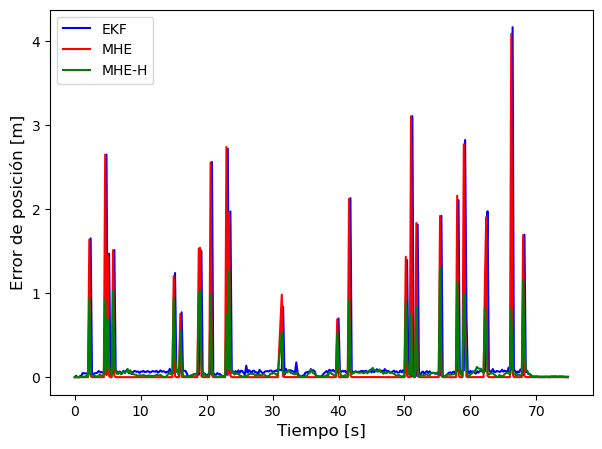

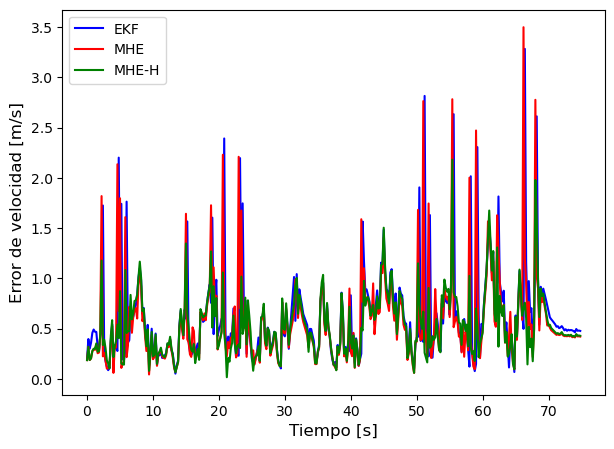

In [16]:
# Graficar errores de posición y velocidad
plt.figure(figsize=(7, 5))
plt.plot(gps_t, pe_ekf, 'b', label='EKF')
plt.plot(gps_t, pe_mhe, 'r', label='MHE')
plt.plot(gps_t, pe_mheh, 'g', label='MHE-H')
plt.xlabel('Tiempo [s]', size=12)
plt.ylabel('Error de posición [m]', size=12)
plt.legend()
plt.savefig('position_error.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(gps_t, v_e, 'b', label='EKF')
plt.plot(gps_t, v_m, 'r', label='MHE')
plt.plot(gps_t, v_h, 'g', label='MHE-H')
plt.xlabel('Tiempo [s]', size=12)
plt.ylabel('Error de velocidad [m/s]', size=12)
plt.legend()
plt.savefig('velocity_error.pdf', bbox_inches='tight')
plt.show()